# Patient Level

## Cell 1: Import Libraries

In [1]:
# Cell 1: Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import LeaveOneOut, train_test_split
import os
import glob
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Cell 2: Compact CNN Model

In [19]:
# Cell 2: Compact CNN Model
class CompactOCTCNN(nn.Module):
    def __init__(self, input_channels=1, num_classes=2):
        super(CompactOCTCNN, self).__init__()
        
        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(input_channels, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

## Cell 3: Patient-Level Dataset Class

In [20]:
# Cell 3: Patient-Level Dataset Class
class PatientLevelDataset(Dataset):
    """Dataset for patient-level training (all frames from a patient as one sample)"""
    def __init__(self, patient_data, transform=None):
        self.patient_data = patient_data  # List of (frames, label, patient_id)
        self.transform = transform
        
    def __len__(self):
        return len(self.patient_data)
    
    def __getitem__(self, idx):
        frames, label, patient_id = self.patient_data[idx]
        frames = torch.FloatTensor(frames)
        if self.transform:
            frames = self.transform(frames)
        return frames, label

## Cell 4: Data Loader Functions for Patient-Level (Fixed Version)

In [21]:
# Cell 4: Data Loader Functions for Patient-Level (Fixed Version)
def load_and_preprocess_image(img_path, img_size=64):
    """Load and preprocess a single image"""
    img = Image.open(img_path)
    if img.mode != 'L':
        img = img.convert('L')
    img = img.resize((img_size, img_size))
    img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array

def load_patient_level_data(data_dir, img_size=64):
    """
    Load data for patient-level training
    Directory structure: MS/patient1/frame1.png, frame2.png, ...
    """
    patient_data = []
    class_mapping = {'MS': 1, 'Control': 0}
    
    for class_name, class_label in class_mapping.items():
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: {class_dir} does not exist")
            continue
            
        # Get all patient folders
        patients = [p for p in os.listdir(class_dir) 
                   if os.path.isdir(os.path.join(class_dir, p))]
        
        print(f"Loading {class_name} data from {len(patients)} patients...")
        
        for patient in patients:
            patient_dir = os.path.join(class_dir, patient)
            image_files = glob.glob(os.path.join(patient_dir, "*.png")) + \
                         glob.glob(os.path.join(patient_dir, "*.jpg")) + \
                         glob.glob(os.path.join(patient_dir, "*.jpeg"))
            image_files.sort()
            
            if not image_files:
                print(f"No images found for patient {patient}")
                continue
                
            frames = []
            for img_path in image_files:
                try:
                    img = load_and_preprocess_image(img_path, img_size)
                    frames.append(img)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    continue
            
            if frames:
                # Don't stack frames here - return as list
                # We'll handle the stacking in prepare_patient_level_data
                patient_data.append((frames, class_label, f"{class_name}_{patient}"))
    
    return patient_data

def prepare_patient_level_data(patient_data, num_frames=7):
    """Prepare patient-level data with fixed number of frames"""
    processed_data = []
    
    for frames_list, label, patient_id in patient_data:
        # Convert list of frames to numpy array
        frames_array = np.array(frames_list)  # This will have shape (n_frames, height, width)
        
        if frames_array.shape[0] >= num_frames:
            # Take first num_frames frames
            selected_frames = frames_array[:num_frames]
        else:
            # Pad with last frame if not enough frames
            last_frame = frames_array[-1]
            padding = np.stack([last_frame] * (num_frames - frames_array.shape[0]), axis=0)
            selected_frames = np.concatenate([frames_array, padding], axis=0)
        
        processed_data.append((selected_frames, label, patient_id))
    
    return processed_data

## Cell 5: Training and Evaluation Classes (Updated with Sensitivity & Specificity)

In [22]:
# Cell 5: Training and Evaluation Classes (Updated with Sensitivity & Specificity)
class OCTTrainer:
    def __init__(self, model, device, criterion, optimizer):
        self.model = model
        self.device = device
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
    def train_epoch(self, dataloader):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for data, target in dataloader:
            data, target = data.to(self.device), target.to(self.device)
            
            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
        
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def validate_epoch(self, dataloader):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in dataloader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                loss = self.criterion(output, target)
                
                running_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def train(self, train_loader, val_loader, epochs, verbose=True):
        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.validate_epoch(val_loader)
            
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            
            if verbose:
                print(f'Epoch {epoch+1}/{epochs}:')
                print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
                print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
                print('-' * 50)

class ModelEvaluator:
    @staticmethod
    def evaluate_model(model, dataloader, device):
        model.eval()
        all_predictions = []
        all_targets = []
        all_probabilities = []
        
        with torch.no_grad():
            for data, target in dataloader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                probabilities = torch.softmax(output, dim=1)
                _, predicted = torch.max(output, 1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(target.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())
        
        return np.array(all_predictions), np.array(all_targets), np.array(all_probabilities)
    
    @staticmethod
    def calculate_metrics(predictions, targets, probabilities):
        accuracy = accuracy_score(targets, predictions)
        precision = precision_score(targets, predictions, average='binary', zero_division=0)
        recall = recall_score(targets, predictions, average='binary', zero_division=0)
        f1 = f1_score(targets, predictions, average='binary', zero_division=0)
        
        # Calculate Sensitivity (Recall) and Specificity
        cm = confusion_matrix(targets, predictions)
        
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        else:
            # Handle cases where confusion matrix is not 2x2
            sensitivity = recall  # Sensitivity is same as recall
            specificity = 0
            if len(np.unique(targets)) == 2:
                # If both classes are present but CM is not 2x2, calculate manually
                tn = np.sum((predictions == 0) & (targets == 0))
                fp = np.sum((predictions == 1) & (targets == 0))
                fn = np.sum((predictions == 0) & (targets == 1))
                tp = np.sum((predictions == 1) & (targets == 1))
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        auc = roc_auc_score(targets, probabilities[:, 1]) if len(np.unique(targets)) > 1 else 0.5
        
        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'auc': auc,
            'confusion_matrix': cm
        }
        
        return metrics
    
    @staticmethod
    def print_metrics(metrics, title="Model Evaluation Metrics"):
        print(f"\n{title}")
        print("=" * 60)
        print(f"Accuracy:     {metrics['accuracy']:.4f}")
        print(f"Precision:    {metrics['precision']:.4f}")
        print(f"Recall:       {metrics['recall']:.4f}")
        print(f"F1-Score:     {metrics['f1_score']:.4f}")
        print(f"Sensitivity:  {metrics['sensitivity']:.4f}")
        print(f"Specificity:  {metrics['specificity']:.4f}")
        print(f"AUC:          {metrics['auc']:.4f}")
        print("\nConfusion Matrix:")
        print(metrics['confusion_matrix'])

## Cell 6: Visualization Functions

In [23]:
# Cell 6: Visualization Functions
def plot_training_history(trainer):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(trainer.train_losses, label='Training Loss')
    ax1.plot(trainer.val_losses, label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(trainer.train_accuracies, label='Training Accuracy')
    ax2.plot(trainer.val_accuracies, label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_auc_curve(targets, probabilities, model_name="Model"):
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(targets, probabilities[:, 1])
    auc_score = roc_auc_score(targets, probabilities[:, 1])
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(cm, classes=['Control', 'MS']):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

## Cell 7: Patient-Level Training Pipeline

In [24]:
# Cell 7: Patient-Level Training Pipeline
def train_patient_level(patient_level_data_dir, num_frames=7, img_size=64, batch_size=8, epochs=20, test_size=0.2):
    """Patient-level training pipeline"""
    print("=== PATIENT-LEVEL TRAINING ===")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load patient-level data
    patient_data = load_patient_level_data(patient_level_data_dir, img_size)
    
    if len(patient_data) == 0:
        print("No patient-level data loaded!")
        return None, None, None
    
    print(f"Loaded {len(patient_data)} patients")
    
    # Prepare data with fixed number of frames
    processed_data = prepare_patient_level_data(patient_data, num_frames)
    
    # Split patients
    patients = [data[2] for data in processed_data]  # patient_ids
    labels = [data[1] for data in processed_data]
    
    train_idx, test_idx = train_test_split(range(len(processed_data)), test_size=test_size, 
                                          random_state=42, stratify=labels)
    
    train_data = [processed_data[i] for i in train_idx]
    test_data = [processed_data[i] for i in test_idx]
    
    # Further split train for validation
    train_labels = [data[1] for data in train_data]
    train_idx, val_idx = train_test_split(range(len(train_data)), test_size=0.2, 
                                         random_state=42, stratify=train_labels)
    
    val_data = [train_data[i] for i in val_idx]
    train_data = [train_data[i] for i in train_idx]
    
    print(f"Training patients: {len(train_data)}")
    print(f"Validation patients: {len(val_data)}")
    print(f"Test patients: {len(test_data)}")
    
    # Create datasets
    train_dataset = PatientLevelDataset(train_data)
    val_dataset = PatientLevelDataset(val_data)
    test_dataset = PatientLevelDataset(test_data)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model (multiple frames input)
    model = CompactOCTCNN(input_channels=num_frames, num_classes=2)
    model.to(device)
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Train
    trainer = OCTTrainer(model, device, criterion, optimizer)
    trainer.train(train_loader, val_loader, epochs)
    
    # Evaluate
    predictions, targets, probabilities = ModelEvaluator.evaluate_model(model, test_loader, device)
    metrics = ModelEvaluator.calculate_metrics(predictions, targets, probabilities)
    
    ModelEvaluator.print_metrics(metrics, f"Patient-Level Evaluation ({num_frames} frames)")
    plot_training_history(trainer)
    plot_auc_curve(targets, probabilities, f"Patient-Level Model ({num_frames} frames)")
    plot_confusion_matrix(metrics['confusion_matrix'])
    
    return model, trainer, metrics

## Cell 8: Leave-One-Out Cross Validation for Patient-Level 

In [25]:
# Cell 8: Leave-One-Out Cross Validation for Patient-Level (Updated with Sensitivity & Specificity)
def run_patient_level_loocv(patient_level_data_dir, num_frames=7, img_size=64, epochs=15):
    """Run Leave-One-Out Cross Validation for patient-level"""
    print("=== PATIENT-LEVEL LEAVE-ONE-OUT CROSS VALIDATION ===")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load patient-level data
    patient_data = load_patient_level_data(patient_level_data_dir, img_size)
    processed_data = prepare_patient_level_data(patient_data, num_frames)
    
    if len(processed_data) < 2:
        print("Not enough patients for LOOCV!")
        return None, None
        
    patient_ids = [data[2] for data in processed_data]
    labels = [data[1] for data in processed_data]
    
    # LOOCV
    loo = LeaveOneOut()
    all_predictions = []
    all_targets = []
    all_probabilities = []
    all_patient_ids = []
    
    print(f"Running LOOCV on {len(patient_ids)} patients...")
    
    for fold, (train_idx, test_idx) in enumerate(loo.split(patient_ids)):
        test_patient_id = patient_ids[test_idx[0]]
        print(f"\nFold {fold + 1}/{len(patient_ids)} - Testing: {test_patient_id}")
        
        try:
            # Patient-level LOOCV
            train_data = [processed_data[i] for i in train_idx]
            test_data = [processed_data[i] for i in test_idx]
            
            # Further split train for validation
            if len(train_data) > 1:
                train_labels = [data[1] for data in train_data]
                train_idx2, val_idx = train_test_split(range(len(train_data)), test_size=0.2, 
                                                      random_state=42, stratify=train_labels)
                val_data = [train_data[i] for i in val_idx]
                train_data = [train_data[i] for i in train_idx2]
            else:
                val_data = train_data.copy()
            
            train_dataset = PatientLevelDataset(train_data)
            val_dataset = PatientLevelDataset(val_data)
            test_dataset = PatientLevelDataset(test_data)
            
            model = CompactOCTCNN(input_channels=num_frames, num_classes=2)
            model.to(device)
            
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            
            train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
            test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
            
            # Train
            trainer = OCTTrainer(model, device, criterion, optimizer)
            trainer.train(train_loader, val_loader, epochs, verbose=False)
            
            # Evaluate and collect results for aggregation
            predictions, targets, probabilities = ModelEvaluator.evaluate_model(model, test_loader, device)
            if len(targets) > 0:
                all_predictions.extend(predictions)
                all_targets.extend(targets)
                all_probabilities.extend(probabilities)
                all_patient_ids.extend([test_patient_id] * len(targets))
                
                # Calculate metrics for this fold
                fold_metrics = ModelEvaluator.calculate_metrics(predictions, targets, probabilities)
                print(f"  Accuracy: {fold_metrics['accuracy']:.4f}, "
                      f"Sensitivity: {fold_metrics['sensitivity']:.4f}, "
                      f"Specificity: {fold_metrics['specificity']:.4f}, "
                      f"AUC: {fold_metrics['auc']:.4f}")
            else:
                print(f"  No test data available for this fold")
                
        except Exception as e:
            print(f"  Error in fold {fold + 1}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Calculate overall metrics from all collected predictions
    if len(all_targets) > 0:
        all_predictions = np.array(all_predictions)
        all_targets = np.array(all_targets)
        all_probabilities = np.array(all_probabilities)
        
        overall_metrics = ModelEvaluator.calculate_metrics(all_predictions, all_targets, all_probabilities)
        
        print(f"\n{'='*60}")
        print("PATIENT-LEVEL LOOCV OVERALL RESULTS")
        print(f"{'='*60}")
        ModelEvaluator.print_metrics(overall_metrics, "Patient-Level LOOCV Overall Metrics")
        
        # Also calculate per-patient metrics
        patient_metrics = {}
        unique_patients = list(set(all_patient_ids))
        
        print(f"\nPer-patient results:")
        print(f"{'Patient':<20} {'Accuracy':<10} {'Sensitivity':<12} {'Specificity':<12} {'Prediction':<12} {'True Label':<12}")
        print("-" * 80)
        
        for patient in unique_patients:
            patient_mask = np.array([pid == patient for pid in all_patient_ids])
            if np.sum(patient_mask) > 0:
                patient_pred = all_predictions[patient_mask]
                patient_true = all_targets[patient_mask]
                patient_probs = all_probabilities[patient_mask]
                
                # Calculate metrics for this patient
                patient_metrics_single = ModelEvaluator.calculate_metrics(patient_pred, patient_true, patient_probs)
                
                pred_label = "MS" if patient_pred[0] == 1 else "Control"
                true_label = "MS" if patient_true[0] == 1 else "Control"
                
                print(f"{patient:<20} {patient_metrics_single['accuracy']:.4f}     "
                      f"{patient_metrics_single['sensitivity']:.4f}       "
                      f"{patient_metrics_single['specificity']:.4f}       "
                      f"{pred_label:<12} {true_label:<12}")
        
        return overall_metrics, None
    
    print("No valid predictions collected from LOOCV!")
    return None, None

## Cell 9: Data Exploration for Patient-Level

In [26]:
# Cell 9: Data Exploration for Patient-Level (Fixed Version)
def explore_patient_level_data(data_dir):
    """Explore patient-level dataset structure"""
    print("Patient-Level Data Exploration")
    print("=" * 50)
    
    patient_data = load_patient_level_data(data_dir)
    print(f"Total patients: {len(patient_data)}")
    
    if len(patient_data) == 0:
        print("No patient data found!")
        return
    
    ms_patients = [p for p in patient_data if p[1] == 1]
    control_patients = [p for p in patient_data if p[1] == 0]
    
    print(f"MS patients: {len(ms_patients)}")
    print(f"Control patients: {len(control_patients)}")
    
    # Frame statistics
    ms_frames = sum([len(p[0]) for p in ms_patients])  # Use len() instead of shape[0]
    control_frames = sum([len(p[0]) for p in control_patients])
    
    print(f"MS frames: {ms_frames}")
    print(f"Control frames: {control_frames}")
    print(f"Total frames: {ms_frames + control_frames}")
    
    # Frames per patient
    frames_per_patient = [len(p[0]) for p in patient_data]  # Use len() instead of shape[0]
    print(f"\nFrames per patient:")
    print(f"  Min: {min(frames_per_patient)}")
    print(f"  Max: {max(frames_per_patient)}")
    print(f"  Mean: {np.mean(frames_per_patient):.2f}")
    print(f"  Std: {np.std(frames_per_patient):.2f}")
    
    # Plot distribution
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(frames_per_patient, bins=20, alpha=0.7, color='skyblue')
    plt.xlabel('Frames per Patient')
    plt.ylabel('Frequency')
    plt.title('Distribution of Frames per Patient')
    
    plt.subplot(1, 2, 2)
    classes = ['Control', 'MS']
    counts = [len(control_patients), len(ms_patients)]
    plt.bar(classes, counts, color=['lightblue', 'lightcoral'])
    plt.xlabel('Class')
    plt.ylabel('Number of Patients')
    plt.title('Class Distribution (Patient-Level)')
    
    plt.tight_layout()
    plt.show()

## Cell 10: Main Patient-Level Analysis

OCT Image Classification - PATIENT-LEVEL ANALYSIS
Patient-Level Data Exploration
Loading MS data from 21 patients...
Loading Control data from 14 patients...
Total patients: 35
MS patients: 21
Control patients: 14
MS frames: 147
Control frames: 98
Total frames: 245

Frames per patient:
  Min: 7
  Max: 7
  Mean: 7.00
  Std: 0.00


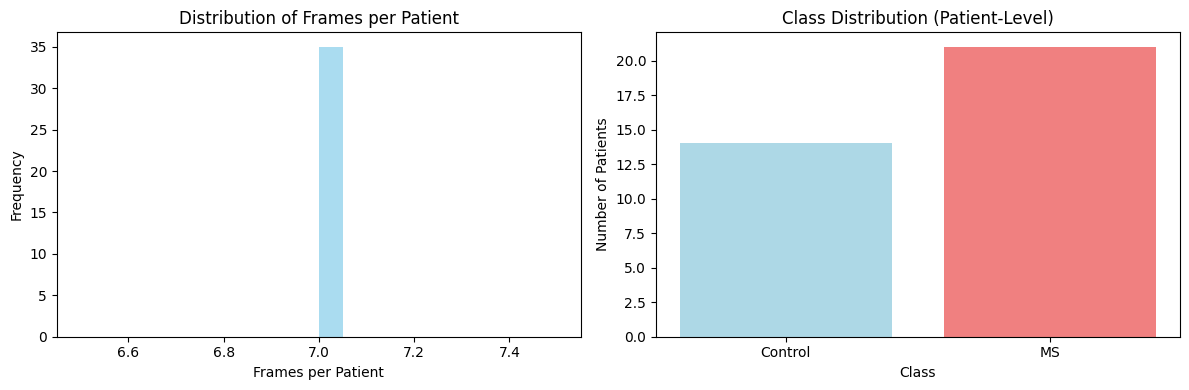


STANDARD TRAINING (70-20-10 Split)
=== PATIENT-LEVEL TRAINING ===
Using device: cuda
Loading MS data from 21 patients...
Loading Control data from 14 patients...
Loaded 35 patients
Training patients: 22
Validation patients: 6
Test patients: 7
Model parameters: 164,642
Epoch 1/100:
  Train Loss: 0.7242, Train Acc: 50.00%
  Val Loss: 0.6918, Val Acc: 66.67%
--------------------------------------------------
Epoch 2/100:
  Train Loss: 0.6741, Train Acc: 63.64%
  Val Loss: 0.6938, Val Acc: 33.33%
--------------------------------------------------
Epoch 3/100:
  Train Loss: 0.5648, Train Acc: 72.73%
  Val Loss: 0.7199, Val Acc: 33.33%
--------------------------------------------------
Epoch 4/100:
  Train Loss: 0.6601, Train Acc: 72.73%
  Val Loss: 0.7476, Val Acc: 33.33%
--------------------------------------------------
Epoch 5/100:
  Train Loss: 0.3898, Train Acc: 81.82%
  Val Loss: 0.8097, Val Acc: 33.33%
--------------------------------------------------
Epoch 6/100:
  Train Loss: 0.4

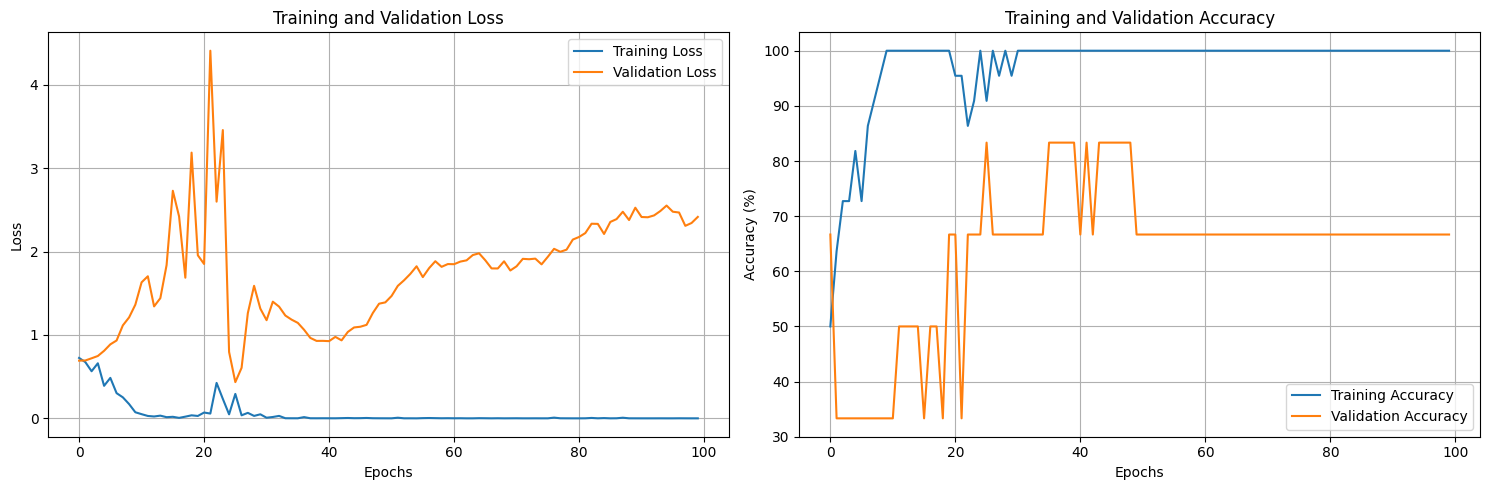

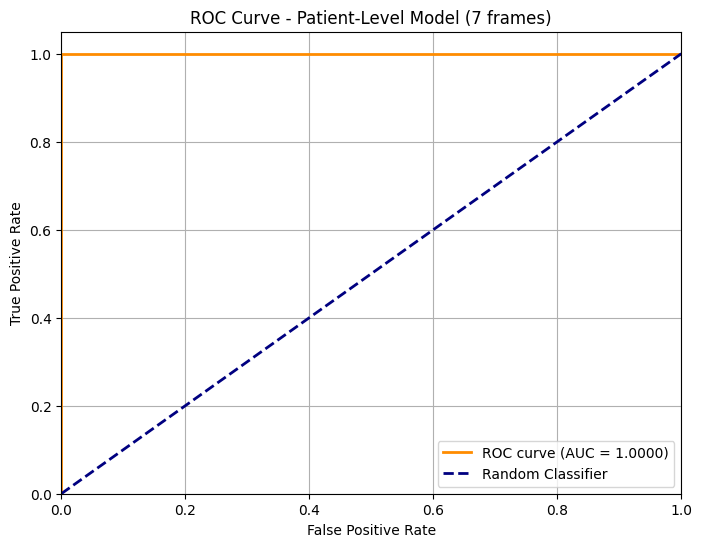

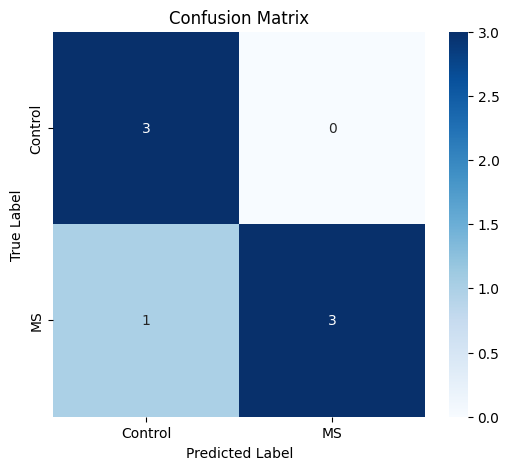


LEAVE-ONE-OUT CROSS VALIDATION
=== PATIENT-LEVEL LEAVE-ONE-OUT CROSS VALIDATION ===
Loading MS data from 21 patients...
Loading Control data from 14 patients...
Running LOOCV on 35 patients...

Fold 1/35 - Testing: MS_ms07_spectralis_macula_v1_s1_R
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 2/35 - Testing: MS_ms20_spectralis_macula_v1_s1_R
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 3/35 - Testing: MS_ms11_spectralis_macula_v1_s1_R
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 4/35 - Testing: MS_ms21_spectralis_macula_v1_s1_R
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 5/35 - Testing: MS_ms19_spectralis_macula_v1_s1_R
  Accuracy: 0.0000, Sensitivity: 0.0000, Specificity: 0.0000, AUC: 0.5000

Fold 6/35 - Testing: MS_ms16_spectralis_macula_v1_s1_R
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 7/35 - Testing: MS_m

In [27]:
# Cell 10: Main Patient-Level Analysis (Updated with Sensitivity & Specificity)
def main():
    """Main function for Patient-Level Analysis Only"""
    print("OCT Image Classification - PATIENT-LEVEL ANALYSIS")
    print("=" * 60)
    
    # UPDATE THIS PATH to your patient-level data directory
    #PATIENT_LEVEL_DATA_PATH = "/home/tanvirdell3/Downloads/MS Classification/Retina OCT  classification MS vs Normal/Publically available Dataset/Selected Frames Datasest"  # ⬅️ UPDATE THIS PATH
    PATIENT_LEVEL_DATA_PATH = '/home/tanvirdell3/Downloads/caserel-master/Publically available Dataset/Segmentation Folders Data'
    if not os.path.exists(PATIENT_LEVEL_DATA_PATH):
        print(f"Patient-level data path {PATIENT_LEVEL_DATA_PATH} does not exist!")
        print("Please update PATIENT_LEVEL_DATA_PATH with your actual data directory.")
        return
    
    # Explore data
    explore_patient_level_data(PATIENT_LEVEL_DATA_PATH)
    
    # Standard training
    print("\n" + "="*60)
    print("STANDARD TRAINING (70-20-10 Split)")
    print("="*60)
    
    try:
        patient_model, patient_trainer, patient_metrics = train_patient_level(
            PATIENT_LEVEL_DATA_PATH, num_frames=7, epochs=100, batch_size=4
        )
    except Exception as e:
        print(f"Error in standard training: {e}")
        patient_metrics = None
    
    # Leave-One-Out Cross Validation
    print("\n" + "="*60)
    print("LEAVE-ONE-OUT CROSS VALIDATION")
    print("="*60)
    
    try:
        loocv_patient_metrics, all_loocv_metrics = run_patient_level_loocv(
            PATIENT_LEVEL_DATA_PATH, epochs=100
        )
    except Exception as e:
        print(f"Error in LOOCV: {e}")
        loocv_patient_metrics = None
        all_loocv_metrics = None
    
    # Print final comparison
    print_final_results(patient_metrics, loocv_patient_metrics)

def print_final_results(standard_metrics, loocv_metrics):
    """Print final comparison of results with Sensitivity & Specificity"""
    print(f"\n{'='*80}")
    print("FINAL RESULTS SUMMARY - PATIENT-LEVEL ANALYSIS")
    print(f"{'='*80}")
    
    print(f"\n{'Method':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Sensitivity':<12} {'Specificity':<12} {'AUC':<10}")
    print("-" * 100)
    
    if standard_metrics:
        print(f"{'Standard Training':<20} {standard_metrics['accuracy']:.4f}     "
              f"{standard_metrics['precision']:.4f}     {standard_metrics['recall']:.4f}     "
              f"{standard_metrics['f1_score']:.4f}     {standard_metrics['sensitivity']:.4f}        "
              f"{standard_metrics['specificity']:.4f}        {standard_metrics['auc']:.4f}")
    else:
        print(f"{'Standard Training':<20} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<12} {'N/A':<12} {'N/A':<10}")
    
    if loocv_metrics:
        print(f"{'LOOCV':<20} {loocv_metrics['accuracy']:.4f}     "
              f"{loocv_metrics['precision']:.4f}     {loocv_metrics['recall']:.4f}     "
              f"{loocv_metrics['f1_score']:.4f}     {loocv_metrics['sensitivity']:.4f}        "
              f"{loocv_metrics['specificity']:.4f}        {loocv_metrics['auc']:.4f}")
    else:
        print(f"{'LOOCV':<20} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<12} {'N/A':<12} {'N/A':<10}")

# Run the main function
if __name__ == "__main__":
    main()

## Done

# Frame Level

## Cell 2: Compact CNN Model

In [28]:
# Cell 2: Compact CNN Model
class CompactOCTCNN(nn.Module):
    def __init__(self, input_channels=1, num_classes=2):
        super(CompactOCTCNN, self).__init__()
        
        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(input_channels, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

## Cell 3: Frame-Level Dataset Class (Fixed Version)

In [29]:
# Cell 3: Frame-Level Dataset Class (Fixed Version)
class FrameLevelDataset(Dataset):
    """Dataset for frame-level training (each frame is a separate sample)"""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        
        # Ensure images have proper shape
        if len(images) > 0:
            if len(images[0].shape) == 2:
                # Add channel dimension if missing
                self.images = np.expand_dims(images, axis=1)
            elif len(images[0].shape) == 3 and images[0].shape[0] != 1:
                # Reorder dimensions if needed (height, width, channel) -> (channel, height, width)
                self.images = np.transpose(images, (0, 3, 1, 2))
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # Ensure image is float32
        image = image.astype(np.float32)
        
        image = torch.FloatTensor(image)
        if self.transform:
            image = self.transform(image)
            
        return image, label

## Cell 4: Data Loader Functions for Frame-Level (Fixed Version)

In [30]:
# Cell 4: Data Loader Functions for Frame-Level (Fixed Version)
def load_and_preprocess_image(img_path, img_size=64):
    """Load and preprocess a single image"""
    img = Image.open(img_path)
    if img.mode != 'L':
        img = img.convert('L')
    img = img.resize((img_size, img_size))
    img_array = np.array(img, dtype=np.float32) / 255.0
    # Add channel dimension
    img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 64, 64)
    return img_array

def load_frame_level_data(data_dir, img_size=64):
    """
    Load data for frame-level training
    Directory structure: MS/frame1.png, frame2.png, ...
    """
    images = []
    labels = []
    image_paths = []
    
    class_mapping = {'MS': 1, 'Control': 0}
    
    for class_name, class_label in class_mapping.items():
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: {class_dir} does not exist")
            continue
            
        # Get all image files directly in class directory
        image_files = glob.glob(os.path.join(class_dir, "*.png")) + \
                     glob.glob(os.path.join(class_dir, "*.jpg")) + \
                     glob.glob(os.path.join(class_dir, "*.jpeg"))
        image_files.sort()
        
        print(f"Loading {class_name} data: {len(image_files)} frames")
        
        for img_path in image_files:
            try:
                img = load_and_preprocess_image(img_path, img_size)
                images.append(img)
                labels.append(class_label)
                image_paths.append(img_path)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
    
    # Stack all images into a single array
    if images:
        images = np.array(images)  # Shape: (n_samples, 1, 64, 64)
    else:
        images = np.array([])
    
    return images, np.array(labels), image_paths

## Cell 5: Training and Evaluation Classes

In [31]:
# Cell 5: Training and Evaluation Classes
class OCTTrainer:
    def __init__(self, model, device, criterion, optimizer):
        self.model = model
        self.device = device
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
    def train_epoch(self, dataloader):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for data, target in dataloader:
            data, target = data.to(self.device), target.to(self.device)
            
            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
        
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def validate_epoch(self, dataloader):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in dataloader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                loss = self.criterion(output, target)
                
                running_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def train(self, train_loader, val_loader, epochs, verbose=True):
        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.validate_epoch(val_loader)
            
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            
            if verbose:
                print(f'Epoch {epoch+1}/{epochs}:')
                print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
                print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
                print('-' * 50)

class ModelEvaluator:
    @staticmethod
    def evaluate_model(model, dataloader, device):
        model.eval()
        all_predictions = []
        all_targets = []
        all_probabilities = []
        
        with torch.no_grad():
            for data, target in dataloader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                probabilities = torch.softmax(output, dim=1)
                _, predicted = torch.max(output, 1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(target.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())
        
        return np.array(all_predictions), np.array(all_targets), np.array(all_probabilities)
    
    @staticmethod
    def calculate_metrics(predictions, targets, probabilities):
        accuracy = accuracy_score(targets, predictions)
        precision = precision_score(targets, predictions, average='binary', zero_division=0)
        recall = recall_score(targets, predictions, average='binary', zero_division=0)
        f1 = f1_score(targets, predictions, average='binary', zero_division=0)
        
        # Calculate Sensitivity (Recall) and Specificity
        cm = confusion_matrix(targets, predictions)
        
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        else:
            # Handle cases where confusion matrix is not 2x2
            sensitivity = recall  # Sensitivity is same as recall
            specificity = 0
            if len(np.unique(targets)) == 2:
                # If both classes are present but CM is not 2x2, calculate manually
                tn = np.sum((predictions == 0) & (targets == 0))
                fp = np.sum((predictions == 1) & (targets == 0))
                fn = np.sum((predictions == 0) & (targets == 1))
                tp = np.sum((predictions == 1) & (targets == 1))
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        auc = roc_auc_score(targets, probabilities[:, 1]) if len(np.unique(targets)) > 1 else 0.5
        
        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'auc': auc,
            'confusion_matrix': cm
        }
        
        return metrics
    
    @staticmethod
    def print_metrics(metrics, title="Model Evaluation Metrics"):
        print(f"\n{title}")
        print("=" * 60)
        print(f"Accuracy:     {metrics['accuracy']:.4f}")
        print(f"Precision:    {metrics['precision']:.4f}")
        print(f"Recall:       {metrics['recall']:.4f}")
        print(f"F1-Score:     {metrics['f1_score']:.4f}")
        print(f"Sensitivity:  {metrics['sensitivity']:.4f}")
        print(f"Specificity:  {metrics['specificity']:.4f}")
        print(f"AUC:          {metrics['auc']:.4f}")
        print("\nConfusion Matrix:")
        print(metrics['confusion_matrix'])

## Cell 6: Visualization Functions

In [32]:
# Cell 6: Visualization Functions
def plot_training_history(trainer):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(trainer.train_losses, label='Training Loss')
    ax1.plot(trainer.val_losses, label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(trainer.train_accuracies, label='Training Accuracy')
    ax2.plot(trainer.val_accuracies, label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_auc_curve(targets, probabilities, model_name="Model"):
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(targets, probabilities[:, 1])
    auc_score = roc_auc_score(targets, probabilities[:, 1])
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(cm, classes=['Control', 'MS']):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

## Cell 7: Frame-Level Training Pipeline

In [33]:
# Cell 7: Frame-Level Training Pipeline
def train_frame_level(frame_level_data_dir, img_size=64, batch_size=32, epochs=20, test_size=0.2):
    """Frame-level training pipeline"""
    print("=== FRAME-LEVEL TRAINING ===")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load frame-level data
    images, labels, image_paths = load_frame_level_data(frame_level_data_dir, img_size)
    
    if len(images) == 0:
        print("No frame-level data loaded!")
        return None, None, None
    
    print(f"Loaded {len(images)} frames")
    print(f"Class distribution: {np.unique(labels, return_counts=True)}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=test_size, 
                                                        random_state=42, stratify=labels)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, 
                                                      random_state=42, stratify=y_train)
    
    # Create datasets
    train_dataset = FrameLevelDataset(X_train, y_train)
    val_dataset = FrameLevelDataset(X_val, y_val)
    test_dataset = FrameLevelDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model (single frame input)
    model = CompactOCTCNN(input_channels=1, num_classes=2)
    model.to(device)
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Train
    trainer = OCTTrainer(model, device, criterion, optimizer)
    trainer.train(train_loader, val_loader, epochs)
    
    # Evaluate
    predictions, targets, probabilities = ModelEvaluator.evaluate_model(model, test_loader, device)
    metrics = ModelEvaluator.calculate_metrics(predictions, targets, probabilities)
    
    ModelEvaluator.print_metrics(metrics, "Frame-Level Evaluation")
    plot_training_history(trainer)
    plot_auc_curve(targets, probabilities, "Frame-Level Model")
    plot_confusion_matrix(metrics['confusion_matrix'])
    
    return model, trainer, metrics

## Cell 8: Leave-One-Out Cross Validation for Frame-Level

In [34]:
# Cell 8: Leave-One-Out Cross Validation for Frame-Level
def run_frame_level_loocv(frame_level_data_dir, img_size=64, epochs=15):
    """Run Leave-One-Out Cross Validation for frame-level"""
    print("=== FRAME-LEVEL LEAVE-ONE-OUT CROSS VALIDATION ===")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load frame-level data
    images, labels, image_paths = load_frame_level_data(frame_level_data_dir, img_size)
    
    if len(images) < 2:
        print("Not enough frames for LOOCV!")
        return None, None
    
    # Extract patient IDs from file paths for frame-level LOOCV
    patient_ids = []
    for path in image_paths:
        # Extract filename without extension as patient identifier
        filename = os.path.basename(path)
        # Remove extension and get patient ID (assuming format: patientID_frameX.png)
        patient_id = os.path.splitext(filename)[0].split('_')[0]
        patient_ids.append(patient_id)
    
    # LOOCV
    unique_patients = list(set(patient_ids))
    all_predictions = []
    all_targets = []
    all_probabilities = []
    all_patient_ids = []
    
    print(f"Running LOOCV on {len(unique_patients)} unique patients...")
    
    for fold, test_patient in enumerate(unique_patients):
        train_patients = [p for p in unique_patients if p != test_patient]
        
        print(f"\nFold {fold + 1}/{len(unique_patients)} - Testing patient: {test_patient}")
        
        # Filter frames based on patient IDs
        train_frames, train_labels = [], []
        test_frames, test_labels = [], []
        
        for i, patient_id in enumerate(patient_ids):
            if patient_id in train_patients:
                train_frames.append(images[i])
                train_labels.append(labels[i])
            elif patient_id == test_patient:
                test_frames.append(images[i])
                test_labels.append(labels[i])
        
        if not train_frames or not test_frames:
            print(f"  Skipping fold - insufficient data")
            continue
            
        # Split train for validation
        if len(train_frames) > 1:
            X_train, X_val, y_train, y_val = train_test_split(train_frames, train_labels, 
                                                            test_size=0.2, random_state=42, 
                                                            stratify=train_labels)
        else:
            X_train, X_val, y_train, y_val = train_frames, train_frames, train_labels, train_labels
        
        train_dataset = FrameLevelDataset(X_train, y_train)
        val_dataset = FrameLevelDataset(X_val, y_val)
        test_dataset = FrameLevelDataset(test_frames, test_labels)
        
        model = CompactOCTCNN(input_channels=1, num_classes=2)
        model.to(device)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        # Train
        trainer = OCTTrainer(model, device, criterion, optimizer)
        trainer.train(train_loader, val_loader, epochs, verbose=False)
        
        # Evaluate and collect results
        predictions, targets, probabilities = ModelEvaluator.evaluate_model(model, test_loader, device)
        if len(targets) > 0:
            all_predictions.extend(predictions)
            all_targets.extend(targets)
            all_probabilities.extend(probabilities)
            all_patient_ids.extend([test_patient] * len(targets))
            
            # Calculate metrics for this fold
            fold_metrics = ModelEvaluator.calculate_metrics(predictions, targets, probabilities)
            print(f"  Accuracy: {fold_metrics['accuracy']:.4f}, "
                  f"Sensitivity: {fold_metrics['sensitivity']:.4f}, "
                  f"Specificity: {fold_metrics['specificity']:.4f}, "
                  f"AUC: {fold_metrics['auc']:.4f}")
    
    # Calculate overall metrics from all collected predictions
    if len(all_targets) > 0:
        all_predictions = np.array(all_predictions)
        all_targets = np.array(all_targets)
        all_probabilities = np.array(all_probabilities)
        
        overall_metrics = ModelEvaluator.calculate_metrics(all_predictions, all_targets, all_probabilities)
        
        print(f"\n{'='*60}")
        print("FRAME-LEVEL LOOCV OVERALL RESULTS")
        print(f"{'='*60}")
        ModelEvaluator.print_metrics(overall_metrics, "Frame-Level LOOCV Overall Metrics")
        
        # Also calculate per-patient metrics
        unique_patients = list(set(all_patient_ids))
        
        print(f"\nPer-patient results:")
        print(f"{'Patient':<20} {'Frames':<8} {'Accuracy':<10} {'Sensitivity':<12} {'Specificity':<12} {'Prediction':<12} {'True Label':<12}")
        print("-" * 90)
        
        for patient in unique_patients:
            patient_mask = np.array([pid == patient for pid in all_patient_ids])
            if np.sum(patient_mask) > 0:
                patient_pred = all_predictions[patient_mask]
                patient_true = all_targets[patient_mask]
                patient_probs = all_probabilities[patient_mask]
                
                # Calculate metrics for this patient
                patient_metrics_single = ModelEvaluator.calculate_metrics(patient_pred, patient_true, patient_probs)
                
                # Get majority vote for patient-level prediction
                pred_label_majority = 1 if np.sum(patient_pred) > len(patient_pred) / 2 else 0
                true_label = patient_true[0]  # All frames from same patient have same label
                
                pred_label_str = "MS" if pred_label_majority == 1 else "Control"
                true_label_str = "MS" if true_label == 1 else "Control"
                
                print(f"{patient:<20} {len(patient_pred):<8} {patient_metrics_single['accuracy']:.4f}     "
                      f"{patient_metrics_single['sensitivity']:.4f}       "
                      f"{patient_metrics_single['specificity']:.4f}       "
                      f"{pred_label_str:<12} {true_label_str:<12}")
        
        return overall_metrics, None
    
    print("No valid predictions collected from LOOCV!")
    return None, None

## Cell 9: Data Exploration for Frame-Level (Fixed Version)

In [35]:
# Cell 9: Data Exploration for Frame-Level (Fixed Version)
def explore_frame_level_data(data_dir):
    """Explore frame-level dataset structure"""
    print("Frame-Level Data Exploration")
    print("=" * 50)
    
    images, labels, image_paths = load_frame_level_data(data_dir)
    
    if len(images) == 0:
        print("No data found!")
        return
        
    print(f"Total frames: {len(images)}")
    print(f"Image shape: {images[0].shape}")
    
    ms_frames = np.sum(labels == 1)
    control_frames = np.sum(labels == 0)
    
    print(f"MS frames: {ms_frames}")
    print(f"Control frames: {control_frames}")
    
    # Extract unique patients
    patient_ids = []
    for path in image_paths:
        filename = os.path.basename(path)
        patient_id = os.path.splitext(filename)[0].split('_')[0]
        patient_ids.append(patient_id)
    
    unique_patients = list(set(patient_ids))
    print(f"Unique patients: {len(unique_patients)}")
    
    # Frames per patient
    frames_per_patient = []
    for patient in unique_patients:
        patient_frames = sum([1 for pid in patient_ids if pid == patient])
        frames_per_patient.append(patient_frames)
    
    print(f"\nFrames per patient:")
    print(f"  Min: {min(frames_per_patient)}")
    print(f"  Max: {max(frames_per_patient)}")
    print(f"  Mean: {np.mean(frames_per_patient):.2f}")
    print(f"  Std: {np.std(frames_per_patient):.2f}")
    
    # Plot distributions
    plt.figure(figsize=(15, 5))
    
    # Class distribution
    plt.subplot(1, 3, 1)
    classes = ['Control', 'MS']
    counts = [control_frames, ms_frames]
    plt.bar(classes, counts, color=['lightblue', 'lightcoral'])
    plt.xlabel('Class')
    plt.ylabel('Number of Frames')
    plt.title('Class Distribution (Frame-Level)')
    
    # Frames per patient distribution
    plt.subplot(1, 3, 2)
    plt.hist(frames_per_patient, bins=20, alpha=0.7, color='skyblue')
    plt.xlabel('Frames per Patient')
    plt.ylabel('Frequency')
    plt.title('Distribution of Frames per Patient')
    
    # Sample images
    plt.subplot(1, 3, 3)
    sample_indices = np.random.choice(len(images), min(4, len(images)), replace=False)
    for i, idx in enumerate(sample_indices):
        plt.subplot(2, 2, i+1)
        # Remove channel dimension for visualization
        if len(images[idx].shape) == 3:
            img_to_show = images[idx][0]  # Take first channel
        else:
            img_to_show = images[idx]
        plt.imshow(img_to_show)
        plt.title(f"{'MS' if labels[idx] == 1 else 'Control'}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print some sample file names
    print(f"\nSample file names:")
    for i in range(min(5, len(image_paths))):
        print(f"  {os.path.basename(image_paths[i])}")

## Cell 10: Main Frame-Level Analysis (Robust Version)

OCT Image Classification - FRAME-LEVEL ANALYSIS
Checking data shapes...
Debugging Data Shapes
Loading MS data: 147 frames
Loading Control data: 98 frames
Total images: 245
Labels shape: (245,)
Image shape: (1, 64, 64)
Image dtype: float32
Image min/max: 0.082/0.765

Shape distribution:
  (1, 64, 64): 245 images

Fixed image shape: (1, 64, 64)
Frame-Level Data Exploration
Loading MS data: 147 frames
Loading Control data: 98 frames
Total frames: 245
Image shape: (1, 64, 64)
MS frames: 147
Control frames: 98
Unique patients: 35

Frames per patient:
  Min: 7
  Max: 7
  Mean: 7.00
  Std: 0.00


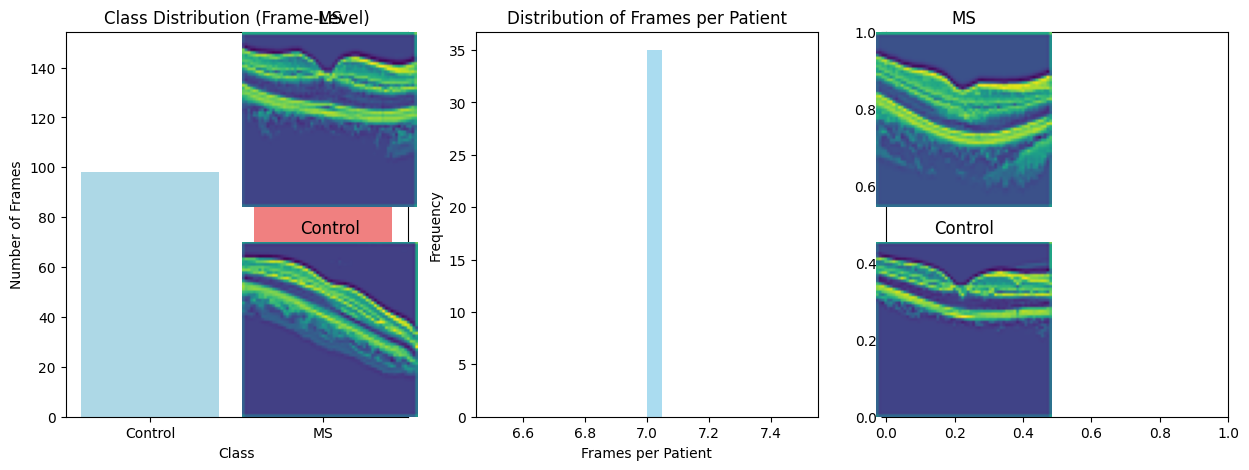


Sample file names:
  ms01_spectralis_macula_v1_s1_R_frame_022_overlay.png
  ms01_spectralis_macula_v1_s1_R_frame_023_overlay.png
  ms01_spectralis_macula_v1_s1_R_frame_024_overlay.png
  ms01_spectralis_macula_v1_s1_R_frame_025_overlay.png
  ms01_spectralis_macula_v1_s1_R_frame_026_overlay.png

STANDARD TRAINING (70-20-10 Split)
=== FRAME-LEVEL TRAINING ===
Using device: cuda
Loading MS data: 147 frames
Loading Control data: 98 frames
Loaded 245 frames
Class distribution: (array([0, 1]), array([ 98, 147]))
Model parameters: 164,210
Epoch 1/100:
  Train Loss: 0.6492, Train Acc: 57.69%
  Val Loss: 0.6928, Val Acc: 60.00%
--------------------------------------------------
Epoch 2/100:
  Train Loss: 0.6171, Train Acc: 62.18%
  Val Loss: 0.6903, Val Acc: 40.00%
--------------------------------------------------
Epoch 3/100:
  Train Loss: 0.4799, Train Acc: 84.62%
  Val Loss: 0.6995, Val Acc: 40.00%
--------------------------------------------------
Epoch 4/100:
  Train Loss: 0.3399, Train A

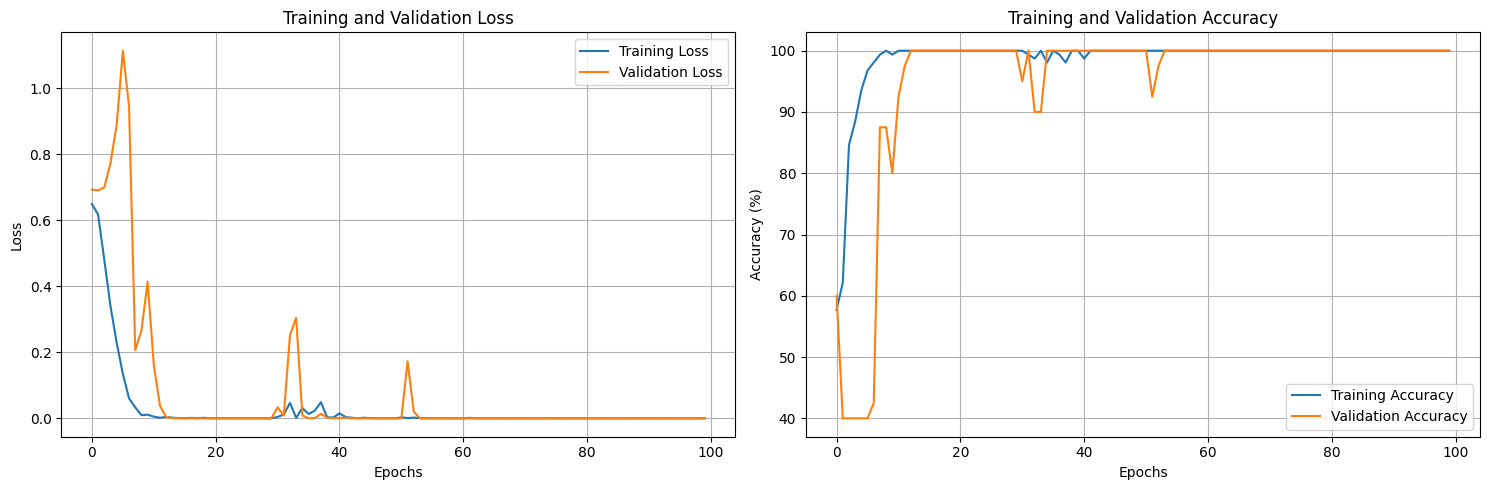

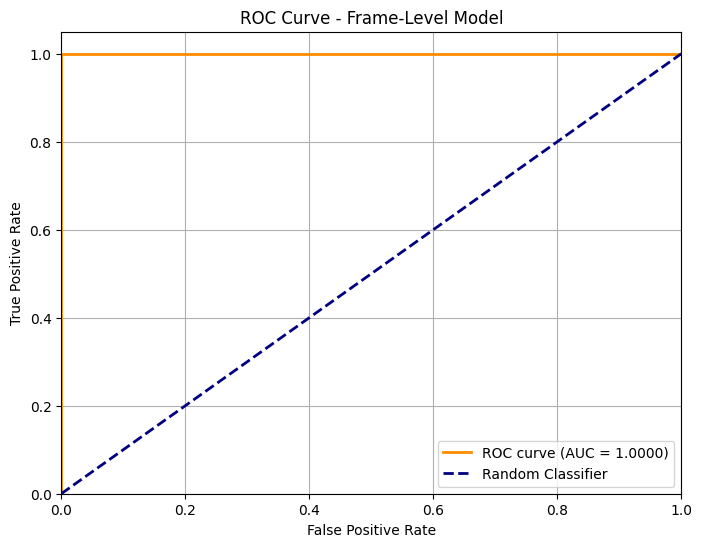

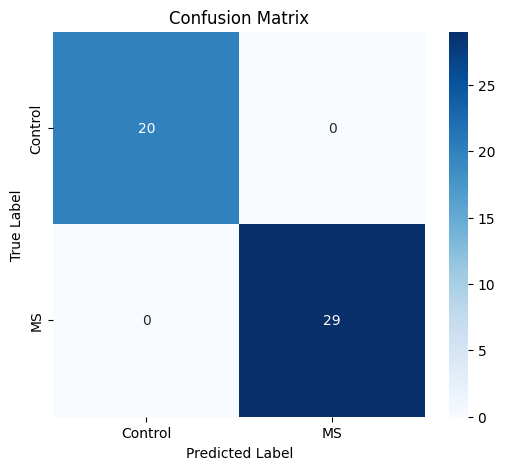


LEAVE-ONE-OUT CROSS VALIDATION
=== FRAME-LEVEL LEAVE-ONE-OUT CROSS VALIDATION ===
Loading MS data: 147 frames
Loading Control data: 98 frames
Running LOOCV on 35 unique patients...

Fold 1/35 - Testing patient: hc13
  Accuracy: 1.0000, Sensitivity: 0.0000, Specificity: 0.0000, AUC: 0.5000

Fold 2/35 - Testing patient: ms16
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 3/35 - Testing patient: ms03
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 4/35 - Testing patient: hc03
  Accuracy: 0.0000, Sensitivity: 0.0000, Specificity: 0.0000, AUC: 0.5000

Fold 5/35 - Testing patient: ms01
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 6/35 - Testing patient: ms08
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 7/35 - Testing patient: ms14
  Accuracy: 1.0000, Sensitivity: 1.0000, Specificity: 0.0000, AUC: 0.5000

Fold 8/35 - Testing patient: ms17
  Accuracy: 0.0000, 

In [36]:
# Cell 10: Main Frame-Level Analysis (Robust Version)
def main():
    """Main function for Frame-Level Analysis Only"""
    print("OCT Image Classification - FRAME-LEVEL ANALYSIS")
    print("=" * 60)
    
    # UPDATE THIS PATH to your frame-level data directory
    #FRAME_LEVEL_DATA_PATH = "/home/tanvirdell3/Downloads/MS Classification/Retina OCT  classification MS vs Normal/Publically available Dataset/Selected Frames All MS-Control"  # ⬅️ UPDATE THIS PATH
    #FRAME_LEVEL_DATA_PATH = '/home/tanvirdell3/Downloads/caserel-master/Publically available Dataset/Segmentation'
    FRAME_LEVEL_DATA_PATH = '/home/tanvirdell3/Downloads/caserel-master/Publically available Dataset/Segmentation Sharpen filter'
    if not os.path.exists(FRAME_LEVEL_DATA_PATH):
        print(f"Frame-level data path {FRAME_LEVEL_DATA_PATH} does not exist!")
        print("Please update FRAME_LEVEL_DATA_PATH with your actual data directory.")
        return
    
    # Debug data shapes first
    print("Checking data shapes...")
    debug_data_shapes(FRAME_LEVEL_DATA_PATH)
    
    # Explore data
    explore_frame_level_data(FRAME_LEVEL_DATA_PATH)
    
    # Standard training
    print("\n" + "="*60)
    print("STANDARD TRAINING (70-20-10 Split)")
    print("="*60)
    
    try:
        frame_model, frame_trainer, frame_metrics = train_frame_level(
            FRAME_LEVEL_DATA_PATH, epochs=100, batch_size=32
        )
    except Exception as e:
        print(f"Error in standard training: {e}")
        import traceback
        traceback.print_exc()
        frame_metrics = None
    
    # Leave-One-Out Cross Validation
    print("\n" + "="*60)
    print("LEAVE-ONE-OUT CROSS VALIDATION")
    print("="*60)
    
    try:
        loocv_frame_metrics, all_loocv_metrics = run_frame_level_loocv(
            FRAME_LEVEL_DATA_PATH, epochs=100
        )
    except Exception as e:
        print(f"Error in LOOCV: {e}")
        import traceback
        traceback.print_exc()
        loocv_frame_metrics = None
        all_loocv_metrics = None
    
    # Print final comparison
    print_final_results(frame_metrics, loocv_frame_metrics)

def print_final_results(standard_metrics, loocv_metrics):
    """Print final comparison of results with Sensitivity & Specificity"""
    print(f"\n{'='*80}")
    print("FINAL RESULTS SUMMARY - FRAME-LEVEL ANALYSIS")
    print(f"{'='*80}")
    
    print(f"\n{'Method':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Sensitivity':<12} {'Specificity':<12} {'AUC':<10}")
    print("-" * 100)
    
    if standard_metrics:
        print(f"{'Standard Training':<20} {standard_metrics['accuracy']:.4f}     "
              f"{standard_metrics['precision']:.4f}     {standard_metrics['recall']:.4f}     "
              f"{standard_metrics['f1_score']:.4f}     {standard_metrics['sensitivity']:.4f}        "
              f"{standard_metrics['specificity']:.4f}        {standard_metrics['auc']:.4f}")
    else:
        print(f"{'Standard Training':<20} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<12} {'N/A':<12} {'N/A':<10}")
    
    if loocv_metrics:
        print(f"{'LOOCV':<20} {loocv_metrics['accuracy']:.4f}     "
              f"{loocv_metrics['precision']:.4f}     {loocv_metrics['recall']:.4f}     "
              f"{loocv_metrics['f1_score']:.4f}     {loocv_metrics['sensitivity']:.4f}        "
              f"{loocv_metrics['specificity']:.4f}        {loocv_metrics['auc']:.4f}")
    else:
        print(f"{'LOOCV':<20} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<12} {'N/A':<12} {'N/A':<10}")

# Run the main function
if __name__ == "__main__":
    main()

## Cell 11: Debug and Utility Functions

In [37]:
# Cell 11: Debug and Utility Functions
def debug_data_shapes(data_dir):
    """Debug function to check data shapes and fix issues"""
    print("Debugging Data Shapes")
    print("=" * 50)
    
    images, labels, image_paths = load_frame_level_data(data_dir)
    
    if len(images) == 0:
        print("No images loaded!")
        return
    
    print(f"Total images: {len(images)}")
    print(f"Labels shape: {labels.shape}")
    
    if len(images) > 0:
        print(f"Image shape: {images[0].shape}")
        print(f"Image dtype: {images[0].dtype}")
        print(f"Image min/max: {images[0].min():.3f}/{images[0].max():.3f}")
    
    # Check for different shapes
    shapes = {}
    for img in images:
        shape = img.shape
        if shape not in shapes:
            shapes[shape] = 0
        shapes[shape] += 1
    
    print(f"\nShape distribution:")
    for shape, count in shapes.items():
        print(f"  {shape}: {count} images")
    
    # Fix common shape issues
    fixed_images = []
    for img in images:
        if len(img.shape) == 2:
            # Add channel dimension: (H, W) -> (1, H, W)
            fixed_img = np.expand_dims(img, axis=0)
        elif len(img.shape) == 3 and img.shape[2] == 1:
            # Change from (H, W, 1) to (1, H, W)
            fixed_img = np.transpose(img, (2, 0, 1))
        elif len(img.shape) == 3 and img.shape[0] == 1:
            # Already correct shape (1, H, W)
            fixed_img = img
        else:
            print(f"Unexpected shape: {img.shape}")
            fixed_img = img
        
        fixed_images.append(fixed_img)
    
    fixed_images = np.array(fixed_images)
    print(f"\nFixed image shape: {fixed_images[0].shape}")
    
    return fixed_images, labels, image_paths

# You can run this function to debug your data
FRAME_LEVEL_DATA_PATH = '/home/tanvirdell3/Downloads/caserel-master/Publically available Dataset/Segmentation'
fixed_images, fixed_labels, fixed_paths = debug_data_shapes(FRAME_LEVEL_DATA_PATH)

Debugging Data Shapes
No images loaded!


TypeError: cannot unpack non-iterable NoneType object

## Done

# Frame level Patient LOOCV

### Cell2: Compact CNN Model

In [5]:
# Cell 2: Compact CNN Model (Single Frame)
class CompactOCTCNN(nn.Module):
    def __init__(self, input_channels=1, num_classes=2):
        super(CompactOCTCNN, self).__init__()
        
        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(input_channels, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

### Cell 3: Frame-Level Dataset Class

In [6]:
# Cell 3: Frame-Level Dataset Class
class FrameLevelDataset(Dataset):
    """Dataset for frame-level training (each frame is a separate sample)"""
    def __init__(self, images, labels, patient_ids=None):
        self.images = images
        self.labels = labels
        self.patient_ids = patient_ids
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # Ensure image has proper shape (1, 64, 64)
        if len(image.shape) == 2:
            image = np.expand_dims(image, axis=0)
        
        image = torch.FloatTensor(image)
        return image, label

### Cell 4: Data Loader Functions

In [7]:
# Cell 4: Data Loader Functions
def load_and_preprocess_image(img_path, img_size=64):
    """Load and preprocess a single image"""
    img = Image.open(img_path)
    if img.mode != 'L':
        img = img.convert('L')
    img = img.resize((img_size, img_size))
    img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array

def load_frame_data_with_patient_info(data_dir, img_size=64):
    """
    Load frame-level data with patient information to prevent data leakage
    Directory structure: MS/patient1_frame1.png, patient1_frame2.png, ...
    """
    images = []
    labels = []
    patient_ids = []
    image_paths = []
    
    class_mapping = {'MS': 1, 'Control': 0}
    
    for class_name, class_label in class_mapping.items():
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: {class_dir} does not exist")
            continue
            
        # Get all image files
        image_files = glob.glob(os.path.join(class_dir, "*.png")) + \
                     glob.glob(os.path.join(class_dir, "*.jpg")) + \
                     glob.glob(os.path.join(class_dir, "*.jpeg"))
        image_files.sort()
        
        print(f"Loading {class_name} data: {len(image_files)} frames")
        
        for img_path in image_files:
            try:
                img = load_and_preprocess_image(img_path, img_size)
                images.append(img)
                labels.append(class_label)
                image_paths.append(img_path)
                
                # Extract patient ID from filename
                filename = os.path.basename(img_path)
                # Assuming format: patientID_frameX.png or similar
                patient_id = filename.split('_')[0]  # Get patient ID part
                patient_ids.append(patient_id)
                
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
    
    return np.array(images), np.array(labels), patient_ids, image_paths

### Cell 5: Training and Evaluation Classes

In [8]:
# Cell 5: Training and Evaluation Classes (Updated with Precision & F1-Score)
class OCTTrainer:
    def __init__(self, model, device, criterion, optimizer):
        self.model = model
        self.device = device
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
    def train_epoch(self, dataloader):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for data, target in dataloader:
            data, target = data.to(self.device), target.to(self.device)
            
            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
        
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def validate_epoch(self, dataloader):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in dataloader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                loss = self.criterion(output, target)
                
                running_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def train(self, train_loader, val_loader, epochs, verbose=True):
        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.validate_epoch(val_loader)
            
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            
            if verbose:
                print(f'Epoch {epoch+1}/{epochs}:')
                print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
                print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
                print('-' * 50)

class ModelEvaluator:
    @staticmethod
    def evaluate_model(model, dataloader, device):
        model.eval()
        all_predictions = []
        all_targets = []
        all_probabilities = []
        
        with torch.no_grad():
            for data, target in dataloader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                probabilities = torch.softmax(output, dim=1)
                _, predicted = torch.max(output, 1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(target.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())
        
        return np.array(all_predictions), np.array(all_targets), np.array(all_probabilities)
    
    @staticmethod
    def calculate_metrics(predictions, targets, probabilities):
        accuracy = accuracy_score(targets, predictions)
        precision = precision_score(targets, predictions, average='binary', zero_division=0)
        recall = recall_score(targets, predictions, average='binary', zero_division=0)
        f1 = f1_score(targets, predictions, average='binary', zero_division=0)
        
        # Calculate Sensitivity and Specificity
        cm = confusion_matrix(targets, predictions)
        
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        else:
            sensitivity = recall
            specificity = 0
            if len(np.unique(targets)) == 2:
                tn = np.sum((predictions == 0) & (targets == 0))
                fp = np.sum((predictions == 1) & (targets == 0))
                fn = np.sum((predictions == 0) & (targets == 1))
                tp = np.sum((predictions == 1) & (targets == 1))
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        auc = roc_auc_score(targets, probabilities[:, 1]) if len(np.unique(targets)) > 1 else 0.5
        
        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'auc': auc,
            'confusion_matrix': cm
        }
        
        return metrics
    
    @staticmethod
    def print_metrics(metrics, title="Model Evaluation Metrics"):
        print(f"\n{title}")
        print("=" * 70)
        print(f"Accuracy:     {metrics['accuracy']:.4f}")
        print(f"Precision:    {metrics['precision']:.4f}")
        print(f"Recall:       {metrics['recall']:.4f}")
        print(f"F1-Score:     {metrics['f1_score']:.4f}")
        print(f"Sensitivity:  {metrics['sensitivity']:.4f}")
        print(f"Specificity:  {metrics['specificity']:.4f}")
        print(f"AUC:          {metrics['auc']:.4f}")
        print("\nConfusion Matrix:")
        print(metrics['confusion_matrix'])

### Cell 6: Patient-Level LOOCV for Frame-Level Data

In [9]:
# Cell 6: Patient-Level LOOCV for Frame-Level Data (Updated with Precision & F1-Score)
def run_patient_level_loocv_frame(data_dir, img_size=64, epochs=15, batch_size=32):
    """
    Run Leave-One-Patient-Out Cross Validation for frame-level data
    This prevents data leakage by ensuring no patient overlap between train and test
    """
    print("=== PATIENT-LEVEL LOOCV FOR FRAME-LEVEL DATA ===")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load data with patient information
    images, labels, patient_ids, image_paths = load_frame_data_with_patient_info(data_dir, img_size)
    
    if len(images) == 0:
        print("No data loaded!")
        return None, None
    
    # Get unique patients
    unique_patients = list(set(patient_ids))
    print(f"Found {len(unique_patients)} unique patients")
    print(f"Total frames: {len(images)}")
    
    # Store results
    all_predictions = []
    all_targets = []
    all_probabilities = []
    all_test_patients = []
    patient_level_results = {}
    
    print(f"\nRunning Leave-One-Patient-Out Cross Validation...")
    
    for fold, test_patient in enumerate(unique_patients):
        print(f"\nFold {fold + 1}/{len(unique_patients)} - Testing Patient: {test_patient}")
        
        # Split data by patient
        train_indices = [i for i, pid in enumerate(patient_ids) if pid != test_patient]
        test_indices = [i for i, pid in enumerate(patient_ids) if pid == test_patient]
        
        if len(train_indices) == 0 or len(test_indices) == 0:
            print(f"  Skipping - no training or test data")
            continue
        
        # Get train and test data
        X_train = images[train_indices]
        y_train = labels[train_indices]
        X_test = images[test_indices]
        y_test = labels[test_indices]
        
        # Further split training data for validation (using patient IDs to prevent leakage)
        train_patients = list(set([patient_ids[i] for i in train_indices]))
        if len(train_patients) > 1:
            # Use one patient for validation
            val_patient = train_patients[0]  # Simple strategy - use first patient
            val_indices = [i for i, pid in enumerate(patient_ids) if pid == val_patient and i in train_indices]
            train_indices_final = [i for i in train_indices if patient_ids[i] != val_patient]
            
            X_train_final = images[train_indices_final]
            y_train_final = labels[train_indices_final]
            X_val = images[val_indices]
            y_val = labels[val_indices]
        else:
            # If only one training patient, use it for both train and val
            X_train_final, X_val, y_train_final, y_val = X_train, X_train, y_train, y_train
        
        print(f"  Training frames: {len(X_train_final)}")
        print(f"  Validation frames: {len(X_val)}")
        print(f"  Test frames: {len(X_test)}")
        
        # Create datasets
        train_dataset = FrameLevelDataset(X_train_final, y_train_final)
        val_dataset = FrameLevelDataset(X_val, y_val)
        test_dataset = FrameLevelDataset(X_test, y_test)
        
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        # Initialize model
        model = CompactOCTCNN(input_channels=1, num_classes=2)
        model.to(device)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        # Train model
        trainer = OCTTrainer(model, device, criterion, optimizer)
        trainer.train(train_loader, val_loader, epochs, verbose=False)
        
        # Evaluate on test set (all frames from left-out patient)
        predictions, targets, probabilities = ModelEvaluator.evaluate_model(model, test_loader, device)
        
        if len(targets) > 0:
            # Calculate metrics for this patient
            patient_metrics = ModelEvaluator.calculate_metrics(predictions, targets, probabilities)
            
            # Store results
            all_predictions.extend(predictions)
            all_targets.extend(targets)
            all_probabilities.extend(probabilities)
            all_test_patients.extend([test_patient] * len(targets))
            
            # Store patient-level results with probabilities
            patient_level_results[test_patient] = {
                'metrics': patient_metrics,
                'predictions': predictions,
                'targets': targets,
                'probabilities': probabilities,  # Store probabilities for AUC
                'num_frames': len(targets)
            }
            
            print(f"  Patient Results:")
            print(f"    Accuracy:    {patient_metrics['accuracy']:.4f}")
            print(f"    Precision:   {patient_metrics['precision']:.4f}")
            print(f"    Recall:      {patient_metrics['recall']:.4f}")
            print(f"    F1-Score:    {patient_metrics['f1_score']:.4f}")
            print(f"    Sensitivity: {patient_metrics['sensitivity']:.4f}")
            print(f"    Specificity: {patient_metrics['specificity']:.4f}")
            print(f"    AUC:         {patient_metrics['auc']:.4f}")
    
    # Calculate overall metrics
    if len(all_targets) > 0:
        overall_metrics = ModelEvaluator.calculate_metrics(
            np.array(all_predictions), 
            np.array(all_targets), 
            np.array(all_probabilities)
        )
        
        print(f"\n{'='*70}")
        print("OVERALL LOOCV RESULTS")
        print(f"{'='*70}")
        ModelEvaluator.print_metrics(overall_metrics, "Overall Frame-Level LOOCV Metrics")
        
        # Print patient-level summary
        print(f"\n{'='*70}")
        print("PATIENT-LEVEL SUMMARY")
        print(f"{'='*70}")
        print(f"{'Patient':<15} {'Frames':<8} {'Accuracy':<10} {'Precision':<10} {'F1-Score':<10} {'Sensitivity':<12} {'Specificity':<12} {'AUC':<8}")
        print("-" * 95)
        
        for patient, results in patient_level_results.items():
            metrics = results['metrics']
            print(f"{patient:<15} {results['num_frames']:<8} {metrics['accuracy']:.4f}     "
                  f"{metrics['precision']:.4f}     {metrics['f1_score']:.4f}     "
                  f"{metrics['sensitivity']:.4f}       {metrics['specificity']:.4f}       "
                  f"{metrics['auc']:.4f}")
        
        return overall_metrics, patient_level_results
    
    print("No valid results collected from LOOCV!")
    return None, None

### Cell 7: Visualization Functions 

In [10]:
# Cell 7: Visualization Functions (Fixed Version)
def plot_training_history(trainer):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(trainer.train_losses, label='Training Loss')
    ax1.plot(trainer.val_losses, label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(trainer.train_accuracies, label='Training Accuracy')
    ax2.plot(trainer.val_accuracies, label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_auc_curve(targets, probabilities, model_name="Model"):
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(targets, probabilities[:, 1])
    auc_score = roc_auc_score(targets, probabilities[:, 1])
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(cm, classes=['Control', 'MS']):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

### Cell 8: Data Exploration

In [11]:
# Cell 8: Data Exploration
def explore_frame_data(data_dir):
    """Explore frame-level dataset with patient information"""
    print("Frame-Level Data Exploration")
    print("=" * 50)
    
    images, labels, patient_ids, image_paths = load_frame_data_with_patient_info(data_dir)
    
    if len(images) == 0:
        print("No data found!")
        return
    
    print(f"Total frames: {len(images)}")
    print(f"Image shape: {images[0].shape}")
    
    ms_frames = np.sum(labels == 1)
    control_frames = np.sum(labels == 0)
    
    print(f"MS frames: {ms_frames}")
    print(f"Control frames: {control_frames}")
    
    # Patient statistics
    unique_patients = list(set(patient_ids))
    ms_patients = list(set([pid for i, pid in enumerate(patient_ids) if labels[i] == 1]))
    control_patients = list(set([pid for i, pid in enumerate(patient_ids) if labels[i] == 0]))
    
    print(f"Unique patients: {len(unique_patients)}")
    print(f"MS patients: {len(ms_patients)}")
    print(f"Control patients: {len(control_patients)}")
    
    # Frames per patient
    frames_per_patient = []
    for patient in unique_patients:
        patient_frames = sum([1 for pid in patient_ids if pid == patient])
        frames_per_patient.append(patient_frames)
    
    print(f"\nFrames per patient:")
    print(f"  Min: {min(frames_per_patient)}")
    print(f"  Max: {max(frames_per_patient)}")
    print(f"  Mean: {np.mean(frames_per_patient):.2f}")
    print(f"  Std: {np.std(frames_per_patient):.2f}")
    
    # Plot distributions
    plt.figure(figsize=(15, 5))
    
    # Class distribution
    plt.subplot(1, 3, 1)
    classes = ['Control', 'MS']
    counts = [control_frames, ms_frames]
    plt.bar(classes, counts, color=['lightblue', 'lightcoral'])
    plt.xlabel('Class')
    plt.ylabel('Number of Frames')
    plt.title('Frame Class Distribution')
    
    # Patient distribution
    plt.subplot(1, 3, 2)
    patient_classes = ['Control', 'MS']
    patient_counts = [len(control_patients), len(ms_patients)]
    plt.bar(patient_classes, patient_counts, color=['lightgreen', 'lightyellow'])
    plt.xlabel('Class')
    plt.ylabel('Number of Patients')
    plt.title('Patient Class Distribution')
    
    # Frames per patient distribution
    plt.subplot(1, 3, 3)
    plt.hist(frames_per_patient, bins=20, alpha=0.7, color='skyblue')
    plt.xlabel('Frames per Patient')
    plt.ylabel('Frequency')
    plt.title('Frames per Patient Distribution')
    
    plt.tight_layout()
    plt.show()

### Cell 9: Main Function

OCT Image Classification - FRAME-LEVEL WITH PATIENT-LEVEL LOOCV
Frame-Level Data Exploration
Loading MS data: 147 frames
Loading Control data: 98 frames
Total frames: 245
Image shape: (64, 64)
MS frames: 147
Control frames: 98
Unique patients: 35
MS patients: 21
Control patients: 14

Frames per patient:
  Min: 7
  Max: 7
  Mean: 7.00
  Std: 0.00


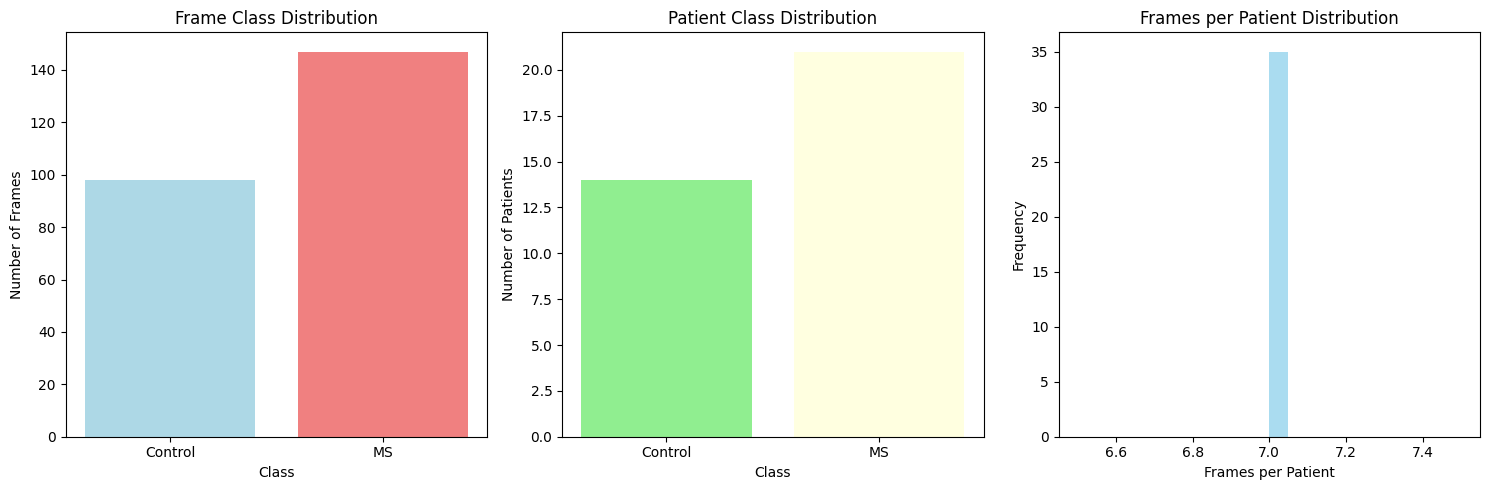


RUNNING PATIENT-LEVEL LEAVE-ONE-OUT CROSS VALIDATION
=== PATIENT-LEVEL LOOCV FOR FRAME-LEVEL DATA ===
Using device: cpu
Loading MS data: 147 frames
Loading Control data: 98 frames
Found 35 unique patients
Total frames: 245

Running Leave-One-Patient-Out Cross Validation...

Fold 1/35 - Testing Patient: ms11
  Training frames: 231
  Validation frames: 7
  Test frames: 7
  Patient Results:
    Accuracy:    1.0000
    Precision:   1.0000
    Recall:      1.0000
    F1-Score:    1.0000
    Sensitivity: 1.0000
    Specificity: 0.0000
    AUC:         0.5000

Fold 2/35 - Testing Patient: ms20
  Training frames: 231
  Validation frames: 7
  Test frames: 7
  Patient Results:
    Accuracy:    1.0000
    Precision:   1.0000
    Recall:      1.0000
    F1-Score:    1.0000
    Sensitivity: 1.0000
    Specificity: 0.0000
    AUC:         0.5000

Fold 3/35 - Testing Patient: ms17
  Training frames: 231
  Validation frames: 7
  Test frames: 7
  Patient Results:
    Accuracy:    0.1429
    Precision:

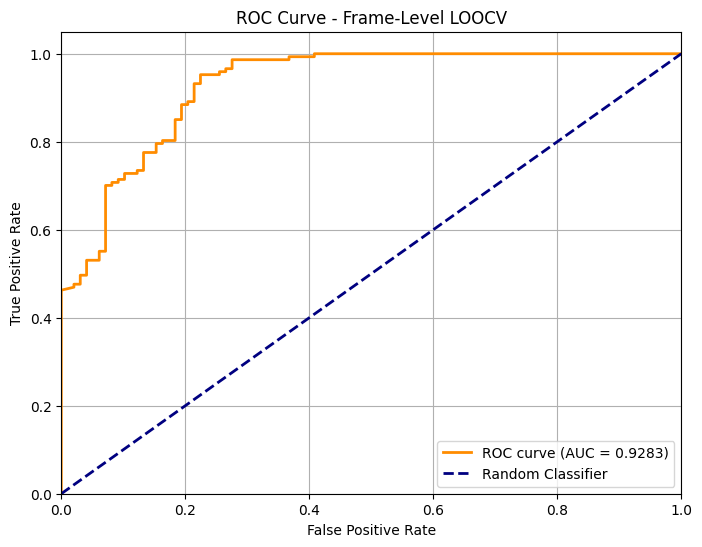

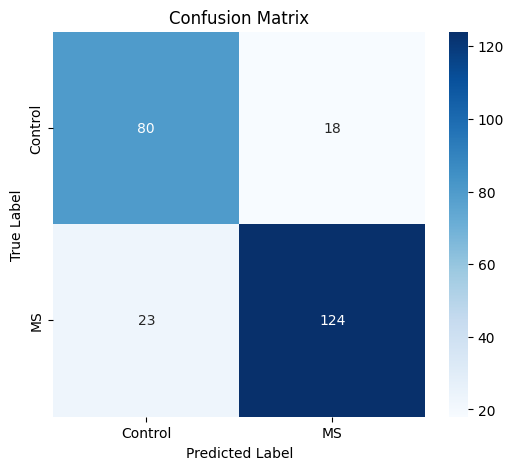


FINAL SUMMARY
Total patients evaluated: 35
Total frames evaluated: 245

Overall Performance:
  Accuracy:    0.8327
  Precision:   0.8732
  Recall:      0.8435
  F1-Score:    0.8581
  Sensitivity: 0.8435
  Specificity: 0.8163
  AUC:         0.9283


In [62]:
# Cell 9: Main Function (Updated with Complete Metrics)
def main():
    """Main function for Frame-Level Analysis with Patient-Level LOOCV"""
    print("OCT Image Classification - FRAME-LEVEL WITH PATIENT-LEVEL LOOCV")
    print("=" * 70)
    
    # UPDATE THIS PATH to your frame-level data directory
    FRAME_LEVEL_DATA_PATH = "/home/tanvirdell3/Downloads/caserel-master/Publically available Dataset/Segmentation Sharpen filter"  # ⬅️ UPDATE THIS PATH
    
    
    if not os.path.exists(FRAME_LEVEL_DATA_PATH):
        print(f"Frame-level data path {FRAME_LEVEL_DATA_PATH} does not exist!")
        print("Please update FRAME_LEVEL_DATA_PATH with your actual data directory.")
        return
    
    # Explore data
    explore_frame_data(FRAME_LEVEL_DATA_PATH)
    
    # Run Patient-Level LOOCV
    print("\n" + "="*70)
    print("RUNNING PATIENT-LEVEL LEAVE-ONE-OUT CROSS VALIDATION")
    print("="*70)
    
    overall_metrics, patient_results = run_patient_level_loocv_frame(
        FRAME_LEVEL_DATA_PATH, epochs=20, batch_size=32
    )
    
    if overall_metrics and patient_results:
        # Collect all targets and probabilities for AUC curve
        all_targets = []
        all_probabilities = []
        
        for patient, results in patient_results.items():
            all_targets.extend(results['targets'])
            all_probabilities.extend(results['probabilities'])
        
        all_targets = np.array(all_targets)
        all_probabilities = np.array(all_probabilities)
        
        # Plot overall results
        plot_auc_curve(all_targets, all_probabilities, "Frame-Level LOOCV")
        plot_confusion_matrix(overall_metrics['confusion_matrix'])
        
        print(f"\n{'='*70}")
        print("FINAL SUMMARY")
        print(f"{'='*70}")
        print(f"Total patients evaluated: {len(patient_results)}")
        print(f"Total frames evaluated: {overall_metrics['confusion_matrix'].sum()}")
        print(f"\nOverall Performance:")
        print(f"  Accuracy:    {overall_metrics['accuracy']:.4f}")
        print(f"  Precision:   {overall_metrics['precision']:.4f}")
        print(f"  Recall:      {overall_metrics['recall']:.4f}")
        print(f"  F1-Score:    {overall_metrics['f1_score']:.4f}")
        print(f"  Sensitivity: {overall_metrics['sensitivity']:.4f}")
        print(f"  Specificity: {overall_metrics['specificity']:.4f}")
        print(f"  AUC:         {overall_metrics['auc']:.4f}")

# Run the main function
if __name__ == "__main__":
    main()

## save

In [25]:
torch.save(model, 'custom_model.pth')  # This saves the complete model object

# Gradcam

In [53]:
def grad_cam_multiple_layers(model, image_path, layer_indices=[8, 10, 12]):
    """
    Try Grad-CAM on different convolutional layers to find the best one
    """
    results = {}
    
    for layer_idx in layer_indices:
        print(f"\n=== Trying Layer {layer_idx} ===")
        
        model.eval()
        activations, gradients = None, None
        
        def forward_hook(module, input, output):
            nonlocal activations
            activations = output.clone()
        
        def backward_hook(module, grad_input, grad_output):
            nonlocal gradients
            gradients = grad_output[0].clone()
        
        # Get target layer
        target_layer = model.conv_layers[layer_idx]
        layer_name = f"Layer_{layer_idx}"
        
        # Register hooks
        forward_handle = target_layer.register_forward_hook(forward_hook)
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        
        # Preprocess
        image = Image.open(image_path).convert('L')
        original_size = image.size
        
        transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])
        
        input_tensor = transform(image).unsqueeze(0)
        input_tensor.requires_grad_(True)
        
        # Forward + backward
        output = model(input_tensor)
        predicted_class = output.argmax(dim=1).item()
        
        model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, predicted_class] = 1.0
        output.backward(gradient=one_hot)
        
        # Generate CAM
        if gradients is not None and activations is not None:
            weights = torch.mean(gradients, dim=[0, 2, 3])
            cam = torch.zeros(activations.shape[2:4])
            
            for i, w in enumerate(weights):
                cam += w * activations[0, i, :, :]
            
            cam = torch.relu(cam)
            cam_normalized = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
            cam_np = cam_normalized.detach().numpy()
            
            # Resize
            cam_resized = cv2.resize(cam_np, original_size)
            
            # Calculate activation metrics
            activation_strength = cam_np.mean()
            activation_area = np.sum(cam_np > 0.1) / cam_np.size
            
            print(f"Activation strength: {activation_strength:.4f}")
            print(f"Activation area: {activation_area:.4f}")
            
            results[layer_name] = {
                'cam': cam_resized,
                'activation_strength': activation_strength,
                'activation_area': activation_area,
                'layer_idx': layer_idx
            }
        
        # Remove hooks
        forward_handle.remove()
        backward_handle.remove()
    
    return results

def visualize_multiple_layers(results, image_path):
    """Visualize results from multiple layers"""
    image = Image.open(image_path).convert('L')
    original_array = np.array(image)
    
    n_layers = len(results)
    fig, axes = plt.subplots(2, n_layers, figsize=(5*n_layers, 10))
    
    if n_layers == 1:
        axes = axes.reshape(2, 1)
    
    for idx, (layer_name, result) in enumerate(results.items()):
        # Top row: CAM
        axes[0, idx].imshow(result['cam'], cmap='jet')
        axes[0, idx].set_title(f'{layer_name}\nStrength: {result["activation_strength"]:.3f}')
        axes[0, idx].axis('off')
        
        # Bottom row: Overlay
        heatmap = cv2.applyColorMap(np.uint8(255 * result['cam']), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        original_rgb = np.stack([original_array] * 3, axis=-1)
        overlay = cv2.addWeighted(original_rgb, 0.6, heatmap, 0.4, 0)
        
        axes[1, idx].imshow(overlay)
        axes[1, idx].set_title(f'Overlay - {layer_name}')
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Find best layer
    best_layer = max(results.items(), key=lambda x: x[1]['activation_strength'])
    print(f"Best layer: {best_layer[0]} with strength {best_layer[1]['activation_strength']:.4f}")
    
    return best_layer[0]

In [54]:
def guided_grad_cam(model, image_path, layer_idx=10):
    """
    Enhanced Grad-CAM with guided backpropagation for sharper visualizations
    """
    # Store original forward functions
    original_fw = {}
    
    def guided_relu_hook(module, grad_in, grad_out):
        # Only backpropagate positive gradients
        return (torch.clamp(grad_in[0], min=0.0),)
    
    # Replace ReLU with guided ReLU
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.ReLU):
            original_fw[name] = module.forward
            module.register_full_backward_hook(guided_relu_hook)
    
    model.eval()
    activations, gradients = None, None
    
    def forward_hook(module, input, output):
        nonlocal activations
        activations = output.clone()
    
    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0].clone()
    
    target_layer = model.conv_layers[layer_idx]
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)
    
    # Preprocess
    image = Image.open(image_path).convert('L')
    original_size = image.size
    
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    input_tensor = transform(image).unsqueeze(0)
    input_tensor.requires_grad_(True)
    
    # Forward + backward
    output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()
    probabilities = F.softmax(output, dim=1)
    
    model.zero_grad()
    one_hot = torch.zeros_like(output)
    one_hot[0, predicted_class] = 1.0
    output.backward(gradient=one_hot)
    
    # Generate enhanced CAM
    if gradients is not None and activations is not None:
        # Use positive gradients only (guided backprop)
        positive_gradients = torch.clamp(gradients, min=0.0)
        weights = torch.mean(positive_gradients, dim=[0, 2, 3])
        
        cam = torch.zeros(activations.shape[2:4])
        for i, w in enumerate(weights):
            cam += w * activations[0, i, :, :]
        
        # Enhanced normalization
        cam = torch.relu(cam)
        
        # Remove low activations (noise reduction)
        cam_flat = cam.flatten()
        threshold = torch.quantile(cam_flat, 0.7)  # Keep top 30%
        cam = torch.where(cam > threshold, cam, torch.tensor(0.0))
        
        cam_normalized = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam_np = cam_normalized.detach().numpy()
        
        # Resize with interpolation
        cam_resized = cv2.resize(cam_np, original_size, interpolation=cv2.INTER_CUBIC)
        
        # Apply Gaussian smoothing for better visualization
        cam_resized = cv2.GaussianBlur(cam_resized, (5, 5), 0)
        cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min() + 1e-8)
        
        # Create overlay
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        original_array = np.array(image.resize(original_size))
        original_rgb = np.stack([original_array] * 3, axis=-1)
        
        overlay = cv2.addWeighted(original_rgb, 0.5, heatmap, 0.5, 0)
        
        # Restore original forward functions
        for name, module in model.named_modules():
            if isinstance(module, torch.nn.ReLU) and name in original_fw:
                module.forward = original_fw[name]
        
        # Remove hooks
        forward_handle.remove()
        backward_handle.remove()
        
        return {
            'cam': cam_resized,
            'overlay': overlay,
            'class_idx': predicted_class,
            'probabilities': probabilities.detach().numpy(),
            'original': original_array
        }
    
    # Cleanup
    forward_handle.remove()
    backward_handle.remove()
    return None

In [55]:
def gradcam_plus_plus(model, image_path, layer_idx=10):
    """
    Grad-CAM++ implementation - often produces better localization
    """
    model.eval()
    activations, gradients = None, None
    
    def forward_hook(module, input, output):
        nonlocal activations
        activations = output.clone()
    
    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0].clone()
    
    target_layer = model.conv_layers[layer_idx]
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)
    
    # Preprocess
    image = Image.open(image_path).convert('L')
    original_size = image.size
    
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    input_tensor = transform(image).unsqueeze(0)
    input_tensor.requires_grad_(True)
    
    # Forward + backward
    output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()
    
    model.zero_grad()
    one_hot = torch.zeros_like(output)
    one_hot[0, predicted_class] = 1.0
    output.backward(gradient=one_hot)
    
    if gradients is not None and activations is not None:
        # Grad-CAM++ weighting
        gradients_square = gradients ** 2
        gradients_cube = gradients ** 3
        
        # Global sum
        global_sum = torch.sum(activations, dim=[2, 3], keepdim=True)
        
        # Alpha calculation (Grad-CAM++ specific)
        numerator = gradients_square
        denominator = 2 * gradients_square + torch.sum(
            activations * gradients_cube, dim=[2, 3], keepdim=True
        ) + 1e-8
        
        alpha = numerator / denominator
        weights = torch.sum(alpha * torch.relu(gradients), dim=[2, 3])
        weights = torch.mean(weights, dim=[0])
        
        # Generate CAM
        cam = torch.zeros(activations.shape[2:4])
        for i, w in enumerate(weights):
            cam += w * activations[0, i, :, :]
        
        cam = torch.relu(cam)
        cam_normalized = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam_np = cam_normalized.detach().numpy()
        
        # Resize
        cam_resized = cv2.resize(cam_np, original_size)
        
        # Create visualization
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        original_array = np.array(image.resize(original_size))
        original_rgb = np.stack([original_array] * 3, axis=-1)
        
        overlay = cv2.addWeighted(original_rgb, 0.6, heatmap, 0.4, 0)
        
        # Remove hooks
        forward_handle.remove()
        backward_handle.remove()
        
        return overlay, predicted_class
    
    forward_handle.remove()
    backward_handle.remove()
    return None, predicted_class


=== Trying Layer 4 ===
Activation strength: 0.4652
Activation area: 0.9836

=== Trying Layer 6 ===
Activation strength: 0.4459
Activation area: 0.9841

=== Trying Layer 8 ===
Activation strength: 0.4975
Activation area: 0.9951

=== Trying Layer 10 ===
Activation strength: 0.4514
Activation area: 0.9961

=== Trying Layer 12 ===
Activation strength: 0.5973
Activation area: 0.9922


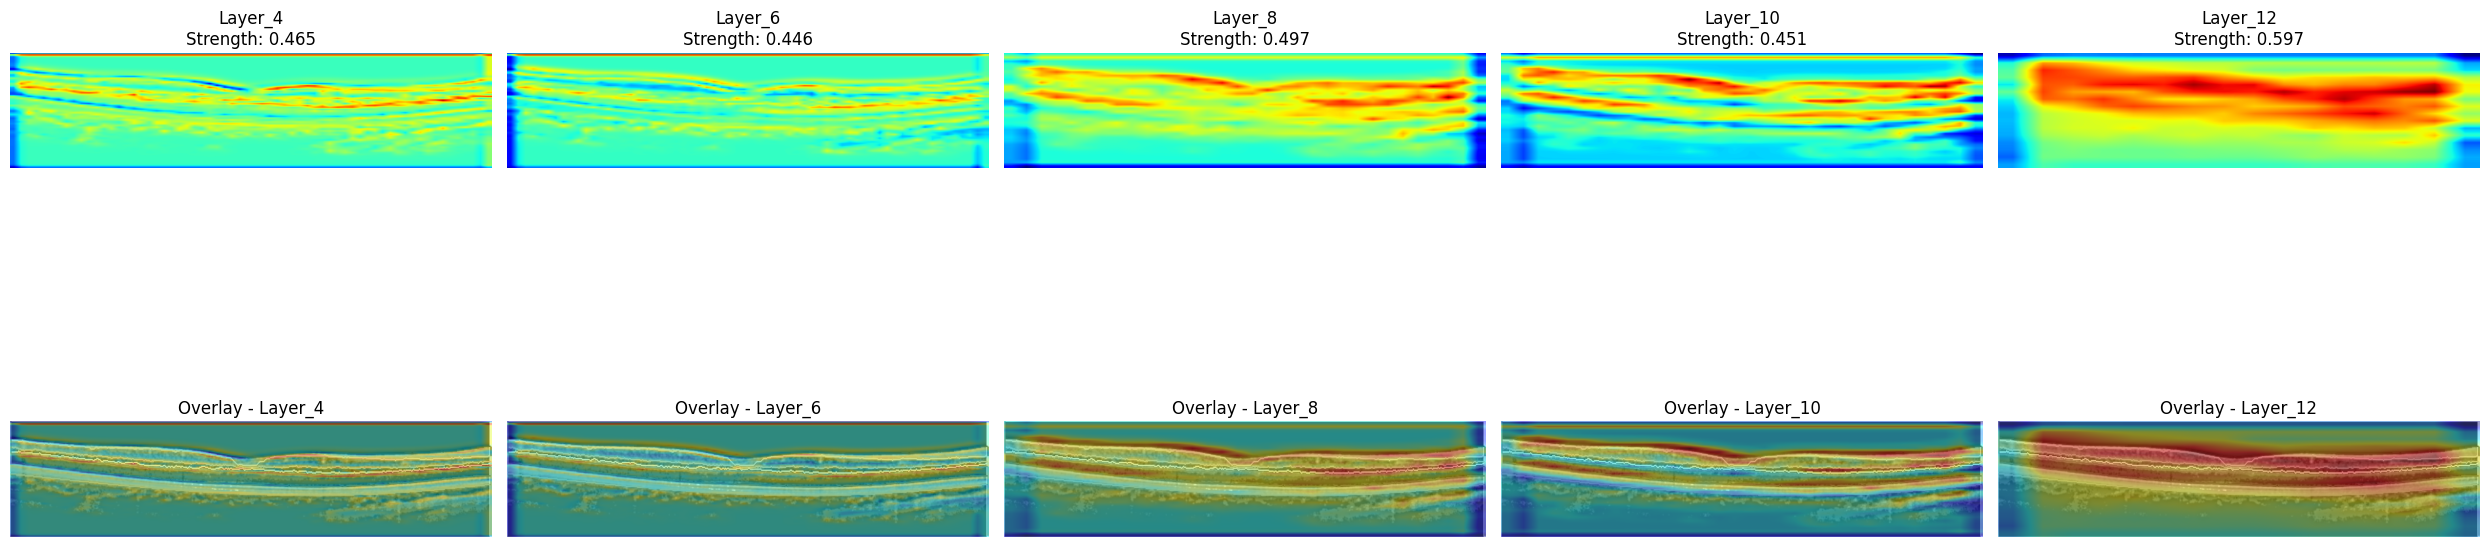

Best layer: Layer_12 with strength 0.5973

Using best layer: Layer_12


In [59]:
# Step 1: Find the best layer
img = '/home/tanvirdell3/Downloads/caserel-master/Publically available Dataset/Segmentation Sharpen filter/MS/ms01_spectralis_macula_v1_s1_R_frame_022_overlay.png'

results = grad_cam_multiple_layers(model, img, layer_indices=[4, 6, 8, 10, 12])
best_layer = visualize_multiple_layers(results, img)

# Step 2: Try enhanced Grad-CAM
print(f"\nUsing best layer: {best_layer}")
result = guided_grad_cam(model, img, layer_idx=int(best_layer.split('_')[1]))

# Step 3: Try Grad-CAM++
overlay, class_idx = gradcam_plus_plus(model, img, layer_idx=int(best_layer.split('_')[1]))

In [60]:
pwd

'/home/tanvirdell3/Downloads/MS Classification/Retina OCT  classification MS vs Normal'